# Module 02 Homework

In [1]:
import pandas as pd
import numpy as np

## Load dataset

In [21]:
data_url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

df_raw = pd.read_csv(data_url)


In [22]:
df_raw.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [23]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  str    
 2   fuel_type            10000 non-null  str    
 3   drivetrain           10000 non-null  str    
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 859.5 KB


In [24]:
# Use only these columns for the homework
hw_cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df_raw[hw_cols].copy()

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


<Axes: ylabel='Frequency'>

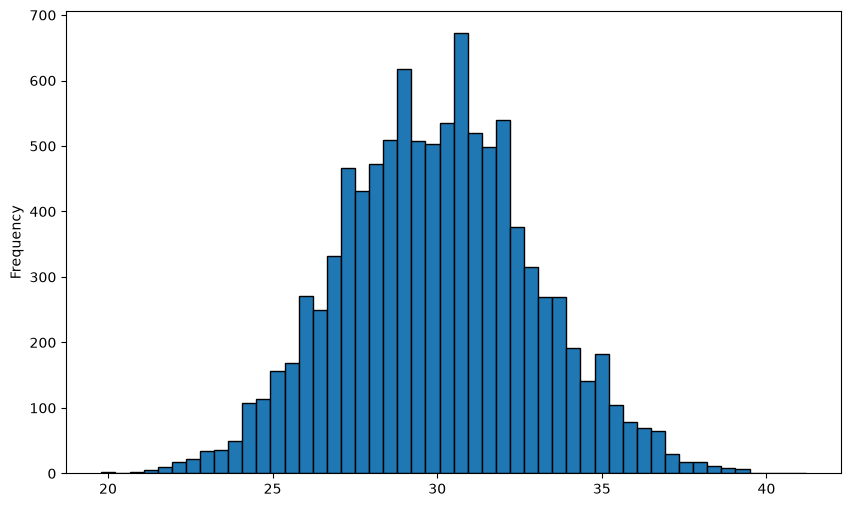

In [27]:
df['fuel_efficiency_mpg'].plot.hist(bins=50, edgecolor='black', figsize=(10, 6))

## Q1

There's one column with missing values. What is it?

In [28]:
df.columns[df.isna().sum()>0].values

<StringArray>
['horsepower']
Length: 1, dtype: str

## Q2

What's the median (50% percentile) for variable 'horsepower'?

In [29]:
df['horsepower'].median()

np.float64(254.0)

## Prepare and split the dataset


In [69]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

## Q3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference * * * visible in this release.
* Which option gives better RMSE?

In [70]:
df_train['horsepower_zero'] = df_train['horsepower'].fillna(0)

fillna_mean = df_train['horsepower'].mean()
df_train['horsepower_mean'] = df_train['horsepower'].fillna(fillna_mean)

In [71]:
X_train_zero = df_train[['engine_displacement', 'horsepower_zero', 'vehicle_weight', 'model_year']].values
X_train_mean = df_train[['engine_displacement', 'horsepower_mean', 'vehicle_weight', 'model_year']].values

y_train = df_train['fuel_efficiency_mpg'].values

In [72]:
# Function to train linear regression model using normal equation in Homework
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [73]:
w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

In [74]:
print(f"Weights for model with zero imputation: w0={w0_zero}, w={w_zero}")
print(f"Weights for model with mean imputation: w0={w0_mean}, w={w_mean}")

Weights for model with zero imputation: w0=-153.8849618823138, w=[-1.51505520e-03 -4.74024794e-06 -3.95418397e-03  1.02146785e-01]
Weights for model with mean imputation: w0=-153.2964563916879, w=[-0.00102386 -0.00648622 -0.00388828  0.10197897]


In [75]:
# RMSE function
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [76]:
X_val_zero = df_val[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].fillna(0).values
X_val_mean = df_val[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].fillna(fillna_mean).values
y_val = df_val['fuel_efficiency_mpg'].values

In [79]:
y_zero_pred = w0_zero + X_val_zero.dot(w_zero)
y_mean_pred = w0_mean + X_val_mean.dot(w_mean)

In [80]:
score_zero = rmse(y_val, y_zero_pred)
score_mean = rmse(y_val, y_mean_pred)

In [81]:
print(f"Score with zero: {round(score_zero, 3)}")
print(f"Score with mean: {round(score_mean, 3)}")

Score with zero: 2.205
Score with mean: 2.202


## Q4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0.
* Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
* Which r gives the best RMSE?
If multiple options give the same best RMSE, select the smallest r.

In [86]:
r_list = [0, 0.01, 0.1, 1, 5, 10, 100]

In [87]:
# Function to train regularized linear regression model using normal equation in Homework
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [91]:
r_scores = []
for r in r_list:
    w0_zero_reg, w_zero_reg = train_linear_regression_reg(X_train_zero, y_train, r)

    y_zero_pred_reg = w0_zero_reg + X_val_zero.dot(w_zero_reg)

    score_zero_reg = round(rmse(y_val, y_zero_pred_reg), 4)

    r_scores.append((r, score_zero_reg))

In [92]:
pd.DataFrame(r_scores, columns=['r', 'score'])

,r,score
0,0.00,2.2053
1,0.01,2.2058
2,0.10,2.2241
3,1.00,2.3492
4,5.00,2.4094
5,10.00,2.4195
6,100.00,2.4292


## Q5

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
* What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
* Round the result to 3 decimal digits (round(std, 3))

What's the value of std?

In [93]:
seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)


In [94]:
rmse_scores = []
for s in seed_values:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train['horsepower_zero'] = df_train['horsepower'].fillna(0)

    X_train_zero = df_train[['engine_displacement', 'horsepower_zero', 'vehicle_weight', 'model_year']].values
    y_train = df_train['fuel_efficiency_mpg'].values

    w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)

    X_val_zero = df_val[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].fillna(0).values
    y_val = df_val['fuel_efficiency_mpg'].values

    y_zero_pred = w0_zero + X_val_zero.dot(w_zero)

    score_zero = rmse(y_val, y_zero_pred)

    rmse_scores.append((s, score_zero))

In [97]:
rmse_values = [i[1] for i in rmse_scores]
rmse_std = np.std(rmse_values)

In [99]:
round(rmse_std, 3)

np.float64(0.029)

## Q6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with r=0.001.

What's the RMSE on the test dataset?

In [107]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [108]:
X_train = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].fillna(0).values
y_train = df['fuel_efficiency_mpg'].values

X_val = df_val[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].fillna(0).values
y_val = df_val['fuel_efficiency_mpg'].values

X_test = df_test[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].fillna(0).values
y_test = df_test['fuel_efficiency_mpg'].values

X_combined = np.vstack([X_train, X_val])
y_combined = np.hstack([y_train, y_val])

In [109]:
r = 0.001

w0_combined, w_combined = train_linear_regression_reg(X_combined, y_combined, r)

In [110]:
y_pred = w0_combined + X_test.dot(w_combined)
score = rmse(y_test, y_pred)
score

np.float64(2.234648163953024)